# Runge Kutta Verfahren für Systeme

Ein **System** erster Ordnung von gDgl

$$
    \vec{y}' = \vec{f}(x, \vec{y}), \qquad \vec{y}(0) = \vec{y}_0
$$

ist definiert durch das **Vektorfeld** 
$$
    \vec{f}(x, \vec{y})
$$
  
* Die **expliziten** numerischen Verfahren für skalare gDgl können ohne Änderung übernommen werden.
* * Die **impliziten** im Prinzip auch, allerdings muss zur Bestimmung von $\vec{y}_{k+1}$ nun jeweils ein System von Gleichungen gelöst werden.

### Newtonverfahren für Systeme für implizite Methoden

In [133]:
import numpy as np
import matplotlib.pyplot as plt

# %% Newtonverfahren 
def newton(g, dg, r, tol = 1e-10, maxStep = 100):
    step = 0
    res = np.linalg.norm(g(r))
    while res > tol and step < maxStep:
        delta = np.linalg.solve(dg(r), g(r)) #...
        r -= delta        
        res = np.linalg.norm(g(r))        
        step += 1        
    assert(step < maxStep)        
    return r

### Beispiel Euler

* Das explizite Verfahren von Euler ist nun

$$
    \vec{y}_{k+1} = \vec{y}_{k} + h \cdot \vec{f}(x_k, \vec{y}_k)
$$

* ... und das implizite
$$
    \vec{y}_{k+1} = \vec{y}_{k} + h \cdot \vec{f}(x_{k+1}, \vec{y}_{k+1})
$$

### Ein lineares Beispiel

Die gDgl mit $\vec{y} \in \mathbb{R}^2$

$$
    \vec{y}' = \begin{pmatrix} 0 & 1 \\ -1 & 0 \end{pmatrix} \cdot \vec{y} \,=\, \begin{pmatrix} y_2 \\ - y_1 \end{pmatrix}
$$

besitzt als Lösungen Kreise mit Zentrum $\vec{0}$. Für das implizite Verfahren von Euler muss in jedem Schritt das Gleichungssystem
$$
    \vec{y}_{k+1} = \vec{y}_{k} + h \cdot \vec{f}(x_{k+1}, \vec{y}_{k+1}) = \vec{y}_{k} + h \cdot A \cdot \vec{y}_{k+1}
$$

gelöst werden. Da die gDgl linear ist, gilt das auch für das Gleichungssystem. Man kann aber trotzdem das Newtonverfahren verwenden und ist einfach nach einem Schritt bereits fertig.

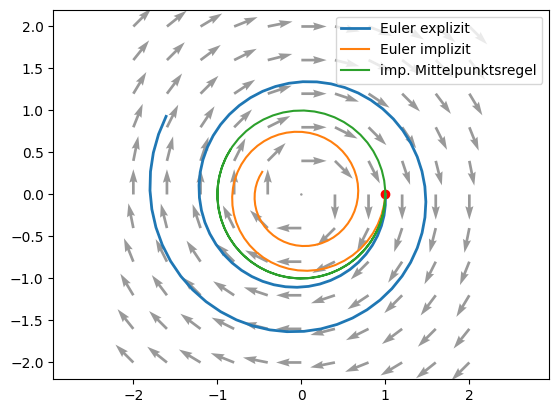

In [134]:
# Vektorfeld (u, v)
u = lambda y1, y2:  y2
v = lambda y1, y2: -y1

# normiert -> ergibt manchmal eine übersichtlichere Darstellung
l = lambda y1, y2: 1e-10 + np.hypot(u(y1, y2), v(y1, y2))
un = lambda y1, y2: u(y1, y2) / l(y1, y2)
vn = lambda y1, y2: v(y1, y2) / l(y1, y2)


y1 = np.linspace(-2, 2, 11)
y2 = np.linspace(-2, 2, 11)

Y1, Y2 = np.meshgrid(y1, y2)

plt.quiver(Y1, Y2, un(Y1, Y2), vn(Y1, Y2), angles = "xy", color = [.6,.6,.6])
plt.axis("equal")

A = np.array([[0,1],[-1,0]])

f = lambda x, y: A @ y
J = lambda x, y: A

# explizites Eulerverfahren
def eulerExp(f, x0, y0, xn, h):
    x = [x0]
    y = [y0]
    while x[-1] < xn - h / 2:
        y.append(y[-1] + h * f(x[-1], y[-1]))
        x.append(x[-1] + h)
    return np.array(x), np.array(y)

# implizites Eulerverfahren
def eulerImp(f, d2f, x0, y0, xn, h):
    dim = len(y0)
    x = [x0]
    y = [y0]
    while x[-1] < xn - h / 2:
        g  = lambda s: y[-1] + h * f(x[-1], s) - s
        dg = lambda s: h * d2f(x[-1], s) - np.eye(dim)
        r = y[-1].copy()
        s = newton(g, dg, r)
        y.append(s)
        x.append(x[-1] + h)
        
    return np.array(x), np.array(y)

# implizite Mittelpunktsregel
def mpImp(f, d2f, x0, y0, xn, h):
    dim = len(y0)
    x = [x0]
    y = [y0]
    r = f(x0, y0) # erster Startwert
    while x[-1] < xn - h / 2:
        # r1 = f(x+h/2, y+h/2*r1)
        g  = lambda r: f(x[-1] + h/2, y[-1] + h/2 * r) - r
        dg = lambda r: h/2 * d2f(x[-1] + h/2, y[-1] + h/2 * r) - np.eye(dim)
        r = newton(g, dg, r)
        y.append(y[-1] + h * r)
        x.append(x[-1] + h)
        
    return np.array(x), np.array(y)

xE, yE = eulerExp(f = f, x0 = 0, y0 = [1., 0], xn = 10, h = 0.125)
xI, yI = eulerImp(f = f, d2f = J, x0 = 0, y0 = [1., 0], xn = 10, h = 0.125)
xM, yM = mpImp(f = f, d2f = J, x0 = 0, y0 = [1., 0], xn = 10, h = 0.125)

plt.scatter(yE[0,0], yE[0,1], color = "r")
plt.plot(yE[:,0], yE[:,1], linewidth = 2, label = "Euler explizit")
plt.plot(yI[:,0], yI[:,1], label = "Euler implizit")
plt.plot(yM[:,0], yM[:,1], label = "imp. Mittelpunktsregel")
plt.legend()

### Beispiel: Lotka-Volterra
Das Räuber-Beute Modell von Lotka-Volterra für die Räuber ($F$ = Foxes) und Beute ($R$ = Rabbits) lautet

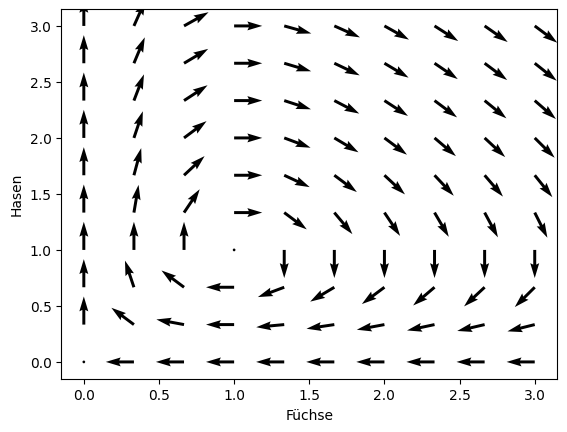

In [128]:

# %% Van der Pol Gleichung

a,b,c,d = 1,1,1,1 # Parameter

u = lambda F, R: - c * F + d * F * R     # F' = u(F, R)
v = lambda F, R:   a * R - b * F * R     # R' = v(F, R)

LV  = lambda F, R : np.array([u(F, R), v(F, R)])
JLV = lambda F, R : np.array([[- c + d * R, d * F],[- b * R, a - b * F]])

f = lambda t, y: LV(*y)     # wrapper, so dass die ode-Funktion immer dieselbe Schnittstelle hat.
d2f = lambda t, y: JLV(*y)  # dasselbe für die Jacobimatrix

norm = lambda F, R: (1e-8+np.hypot(u(F,R), v(F,R)))

uNormed = lambda F, R : u(F,R) / norm(F,R)
vNormed = lambda F, R : v(F,R) / norm(F,R)

x, y = np.linspace(0,3*b/a,10), np.linspace(0, 3*d/c, 10)

X, Y = np.meshgrid(x,y)

plt.quiver(X,Y, uNormed(X,Y), vNormed(X,Y), angles = 'xy', linewidth = .25)
plt.xlabel("Füchse");
plt.ylabel("Hasen");

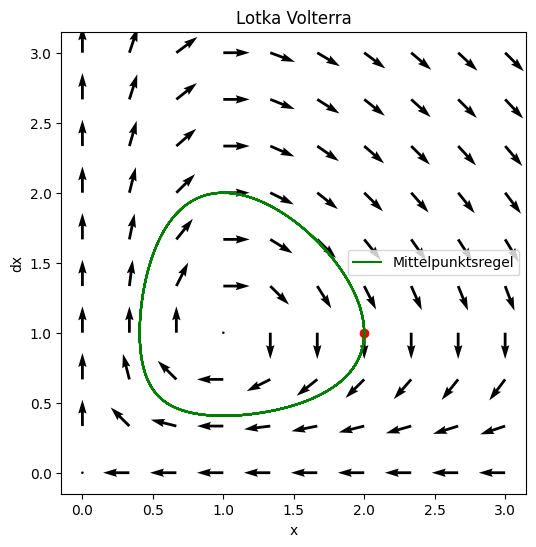

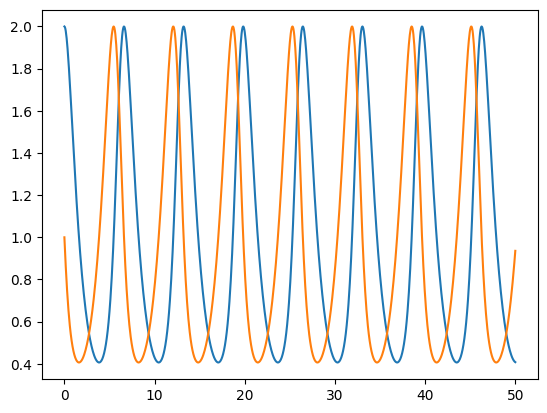

In [129]:
# %% Startwerte und Zeitvektor (fester Zeitschritt!)
x0 = np.array([2., 1])
h = .05
T = [0, 50]
n = int( (T[-1] - T[0]) / h)
# %% Euler
t = np.arange(T[0], T[-1], h)
xE = np.zeros( (n, 2) )
xE[0] = x0

for k in range(n-1):
    xE[k+1] = xE[k] + h * f(t[k], ( xE[k]) )

# %% RK 4
t = np.arange(T[0], T[-1], h)
xRK = np.zeros( (n, 2) )
xRK[0] = x0

for k in range(n-1):
    tc, xc = t[k], xRK[k]
    r1 = f(tc, xc)
    r2 = f(tc + h/2, (xc + h * r1) )
    r3 = f(tc + h/2, (xc + h * r2) )
    r4 = f(tc + h,   (xc + h * r3) )

    xRK[k+1] = xRK[k] + h/6 * (r1 + 2*r2 + 2*r3 + r4)

t, xMP = mpImp(f, d2f, T[0], x0, T[-1], h)

#%% plot
plt.figure(0,[6,6])
plt.quiver(X,Y,uNormed(X,Y), vNormed(X,Y), angles = 'xy', linewidth = .5)
plt.scatter(*x0, color = "red")
# plt.plot(xE[:,0], xE[:,1], 'gold', label = "Euler")
# plt.plot(xRK[:,0], xRK[:,1], 'b', label = "RK4")
plt.plot(xMP[:,0], xMP[:,1], 'g', label = "Mittelpunktsregel")
plt.xlabel('x')
plt.ylabel('dx')
plt.title ('Lotka Volterra')
plt.legend()
plt.show()

plt.figure()
plt.plot(t, xMP)

## Stabilität revisited
Das System

$$
    y'' + 101 \, y' + 100 \, y = 0, \qquad \textrm{bzw} \qquad 
    \vec{y}' = \begin{pmatrix} 0 & 1 \\ -100 & -101 \end{pmatrix} \cdot \vec{y}
$$

mit Anfangsbedingungen $y(0) = 0$, $y'(0) = 99$ besitzt die allgemeine Lösung

$$
    y(x) = e^{-x} - e^{-100 x} 
$$

Die Lösung sieht für $x> 0$ sehr rasch ziemlich genau wie $e^{-x}$ aus, aber die Schrittweite ist durch $e^{-100 x}$ begrenzt.

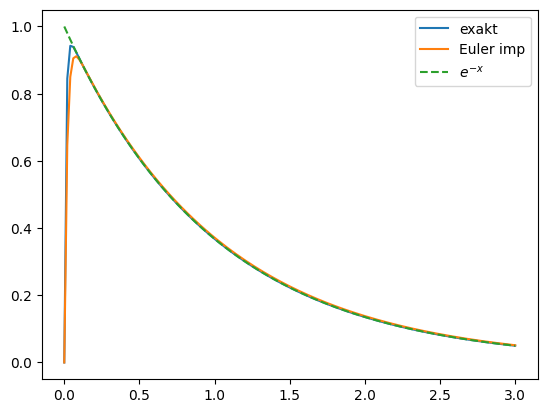

In [137]:
A = np.array([[0.,1],[-100,-101]])

f = lambda x, y: A @ y
d2f  = lambda x, y: A

x0 = 0
y0 = [0, 99]

xn = 3

h = 2 / 100 * 1

yExact = lambda x: np.exp(-x) - np.exp(-100*x)

xE, yE = eulerExp(f, x0, y0, xn, h)
xI, yI = eulerImp(f, d2f, x0, y0, xn, h)

plt.plot(xE, yExact(xE), label = "exakt")
# plt.plot(xE, yE[:,0], label = "Euler exp")
plt.plot(xI, yI[:,0], label = "Euler imp")
plt.plot(xE, np.exp(-xE), '--', label = r"$e^{-x}$")
plt.legend()


### Ein Beispiel mit komplexen Eigenwerten

Ein lineares System $\vec{y}' = A \cdot \vec{y}$ ist **asymptotisch stabil**, wenn alle Eigenwerte von $A$ negativen Realteil haben. Es gilt dann

$$
    \vec{y}(t) \to 0, \qquad (t \to \infty)
$$

Beispiel:

$$
    \vec{y}' = \begin{pmatrix} 0 & 1 \\ -4 & -2 \end{pmatrix} \cdot \vec{y} \quad \implies \quad \lambda = -1 \pm i \cdot \sqrt{3}
$$

Die Lösungskurven in der **Phasenebene** d.h. der $y_1 \, y_2$-Ebene bilden Spiralen Richtung $\vec{0}$

**Euler explizit** rechnet

$$
    \vec{y}_{k+1} = \vec{y}_k + h A \vec{y}_k = (E + h A) \cdot \vec{y}_k
$$

damit dies immer noch asymptotisch stabil ist, müssen die Werte $1 + h \lambda_i$ die Bedingung

$$
    |1 + h \lambda_i| < 1
$$

erfüllen.

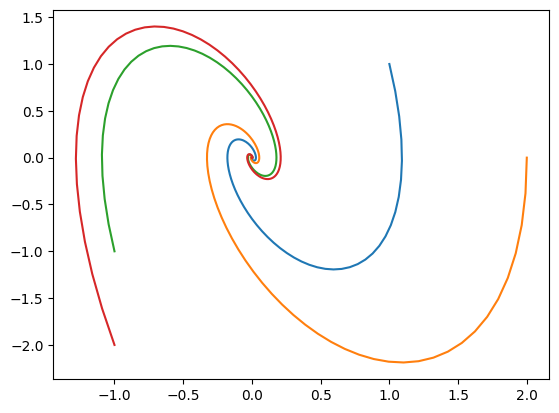

In [161]:
A = np.array([[0.,1],[-4,-2]])
t0 = 0
tn = 10

f  = lambda t, y: A @ y
df = lambda t, y: A

ic = [[1.,1.], [2.,0.], [-1.,-1.], [-1,-2.]]

for y0 in ic:
    x, y = mpImp(f, d2f, x0 = t0, y0 = y0, xn = tn, h = 0.05) 
    plt.plot(y[:,0], y[:,1])

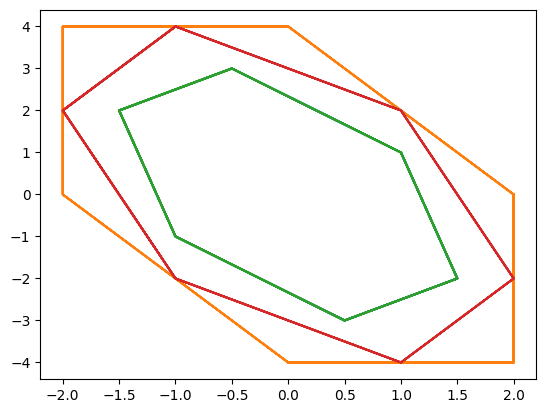

In [162]:
for y0 in ic:
    x, y = eulerExp(f, x0 = t0, y0 = y0, xn = tn, h = 0.5) 
    plt.plot(y[:,0], y[:,1])

### RK4 (mit Schrittweitensteuerung)

In [159]:
# Ein Schritt mit RK 4
def RK4step(x, y, f, h):
    r1 = f(x, y)
    r2 = f(x + h/2, y + h/2 * r1)
    r3 = f(x + h/2, y + h/2 * r2)
    r4 = f(x + h,   y + h   * r3)

    return y + h/6 * (r1 + 2 * r2 + 2 * r3 + r4)
    
def RK4_sws(f, x0, y0, xn, tol = 1e-5):
    p = 4  # Fehlerordnung für RK 4
    h = (xn - x0) / 100 # Startwert für h
    rho = 0.9 # Sicherheitsfaktor
    
    x = [x0]
    y = [y0]

    while (x[-1] < xn - 1e-10):

        
        y1 = RK4step(x[-1], y[-1], f, h)
    
        y12 = RK4step(x[-1],       y[-1], f, h / 2)
        y22 = RK4step(x[-1] + h/2, y12,   f, h / 2)
    
        eta = 10 * np.linalg.norm(y1 - y22) / (1 - 2**(-p)) # zusätzlicher Sicherheitsfaktor in der Fehlerschätzung...

        if (eta < tol):
            x.append(x[-1] + h)
            y.append(y22) # wir nehmen den besseren Wert...
            
        h *= rho * (tol / (eta + 1e-5*tol))**(1/(p+1)) # Schrittweite wird in jedem Fall angepasst
        h = min(h, xn - x[-1]) # damit sollten wir die Endstelle nicht überschreiten

    return np.array(x), np.array(y)

### Am Beispiel des Van der Pol Oszillators 
$$
    y'' = \mu \cdot (1 - y^2) \cdot y' - y
$$

Je grösser der Parameter $\mu$, desto mehr würde sich ein implizites Verfahren anbieten


Text(0.5, 1.0, 'Schrittweiten')

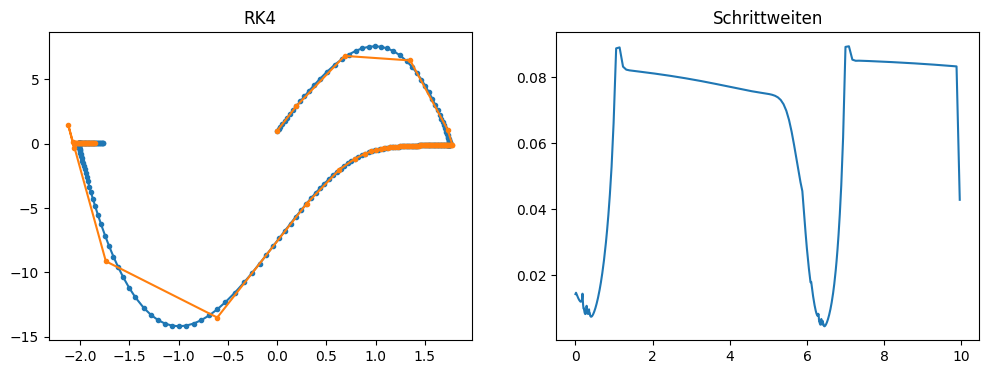

In [160]:
mu = 10
VdP  = lambda y: np.array([y[1], mu * (1 - y[0]**2) * y[1] - y[0]])
JVdP = lambda y: np.array([[0, 1], [-2 * mu * y[0] * y[1] - 1, mu * (1-y[0]**2)]])

f = lambda t, y: VdP(y)
d2f = lambda t, y: JVdP(y)

x0 = 0
y0 = [0., 1]
xn = 10

x, y   = RK4_sws(f, x0, y0, xn) # mit Schrittweitensteuerung
xMP, yMP = mpImp(f, d2f, x0, y0, xn, h = 0.1) # mit fester Schrittweite

fig, ax = plt.subplots(1, 2, figsize = (12, 4))
ax[0].plot(y[:,0], y[:,1], ".-")
ax[0].plot(yMP[:,0], yMP[:,1], ".-")
ax[0].set_title("RK4")
ax[1].plot(x[:-1], np.diff(x))
ax[1].set_title("Schrittweiten")